In [11]:
%load_ext autoreload
%autoreload 2
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
from reward_relative import behavior
import pickle
import dill
import numpy as np
import os 
import matplotlib.pyplot as plt
import TwoPUtils
import protter_functions as pf
from scipy.signal import medfilt
from matplotlib.lines import Line2D
import pandas as pd
import umap
import hdbscan
import importlib

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:


experiment = 'MetaLearn'
year = 'combined'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment, exp_days, year=year)

## These parameters were used for computing the saved multiDayData
# bin_size = 10  # for quantifying distribution of place field peak locations
# sigma = 1  # for smoothing
# smooth = False  # whether to smooth for finding place cell peaks
# exclude_int = True  # exclude putative interneurons
# int_thresh = 0.5

## Place cell logical definitions:
## 'and' = must have significant spatial information
## in trial set 0 AND trial set 1 (i.e. before and after the reward switch)
## 'or' = must have signitive spatial information in trial set 0 OR trial set 1

# place_cell_logical = 'or'
ts_key = 'dff'  # which timeseries to use for finding peaks
# use_speed_thr = True  # use a speed threshold to calculate new trial matrices
# # speed threshold in cm/s (excludes data at speed less than this)
# speed_thr = 2

reward_dist_inclusive = 50  # in cm

# datetime of saved file
dt = "202504"

pkl_name = "%s_expdays%s_multiDayData_%s_%s.pickle" % (
    # ut.make_anim_tag(max_anim_list),
    f'm{ut.get_mouse_number(max_anim_list[0])}-{ut.get_mouse_number(max_anim_list[-1])}',
    ut.make_day_tag(
        exp_days),
    ts_key,
    dt)
pkl_path = os.path.join(
    path_dict['preprocessed_root'], 'multi_anim_sess', pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path, "rb"), ignore=True)

include_ans = multiDayData[exp_days[-1]
                           ].circ_rel_stats_across_an['include_ans']
max_anim_list = sorted(np.unique(np.concatenate([multiDayData[day].anim_list
                                                 for day in exp_days])),
                       key=len)
include_ans

In [ ]:
import importlib
pf = importlib.reload(pf)


In [ ]:

animal_list = include_ans
lick_sessions = {ani:{} for ani in animal_list}

for i, day in enumerate(sorted(exp_days)):
    print(day)
    # load multi_anim_sess that has the spatial activity to plot
    multi_anim_sess = dd.load_multi_anim_sess(path_dict, day, multiDayData[day].anim_list,
                                          subdirs = ['multi_anim_sess'])
    
    for animal in animal_list:
        session = multi_anim_sess[animal]['sess']
        if len(lick_sessions[animal].keys())==0:
            lick_sessions[animal]['trial_info'] = pf.TrialInfo({day:session})
            
            licks = pf.correct_licks(session)
            lick_sessions[animal]['licks_smoothed'] = pf.smooth_trial_matrix(licks)


        else:
            
            lick_sessions[animal]['trial_info'].add_session(day, multi_anim_sess[animal]['sess'])
            licks = pf.correct_licks(session)
            lick_sessions[animal]['licks_smoothed'] = np.concatenate([lick_sessions[animal]['licks_smoothed'],pf.smooth_trial_matrix(licks)])
    del(multi_anim_sess)
    del(session)


In [ ]:
del(multiDayData)

In [ ]:
import gc
import sys

def get_obj_size(obj):
    marked = {id(obj)}
    obj_q = [obj]
    sz = 0

    while obj_q:
        sz += sum(map(sys.getsizeof, obj_q))

        # Lookup all the object referred to by the object in obj_q.
        # See: https://docs.python.org/3.7/library/gc.html#gc.get_referents
        all_refr = ((id(o), o) for o in gc.get_referents(*obj_q))

        # Filter object that are already marked.
        # Using dict notation will prevent repeated objects.
        new_refr = {o_id: o for o_id, o in all_refr if o_id not in marked and not isinstance(o, type)}

        # The new obj_q will be the ones that were not marked,
        # and we will update marked with their ids so we will
        # not traverse them again.
        obj_q = new_refr.values()
        marked.update(new_refr.keys())

    return sz

In [ ]:
get_obj_size(lick_sessions['GCAMP11'])/1e6

In [ ]:
all_obs = 0
for k,obj in lick_sessions.items():
    print(f'{k}, {get_obj_size(obj)/1e6} MB')
    all_obs += get_obj_size(obj)
print(f"sum: {all_obs/1e6} MB")

In [ ]:
lick_sessions['GCAMP11']['trial_info'].lookup_df

In [ ]:

anis = list(lick_sessions.keys())

all_licks, all_trial_info = lick_sessions[anis[0]]['licks_smoothed'], lick_sessions[anis[0]]['trial_info'].lookup_df
all_trial_info['animal'] = anis[0]
for ani in anis[1:]:
    licks, trials = lick_sessions[ani]['licks_smoothed'], lick_sessions[ani]['trial_info'].lookup_df
    trials.idx = trials.idx + all_trial_info.idx.max() + 1
    trials['animal'] = ani
    all_licks = np.concatenate([all_licks, licks])
    all_trial_info = pd.concat([all_trial_info, trials])

In [ ]:
all_trial_info.loc[np.isnan(all_licks).any(axis = 1)].shape

In [ ]:

trials_na_free = all_trial_info.loc[np.logical_not(np.isnan(all_licks).any(axis = 1))].copy()
licks_na_free = all_licks[np.logical_not(np.isnan(all_licks).any(axis = 1))]

In [ ]:
trials_na_free.omit.values

In [ ]:
np.save('protter_tmp_files/all_licks_na_dropped.npy', licks_na_free)
trials_na_free.to_csv('protter_tmp_files/all_licks_na_dropped_trial_info.csv')

In [2]:
licks_na_free = np.load('protter_tmp_files/all_licks_na_dropped.npy')
trials_na_free = pd.read_csv('protter_tmp_files/all_licks_na_dropped_trial_info.csv')

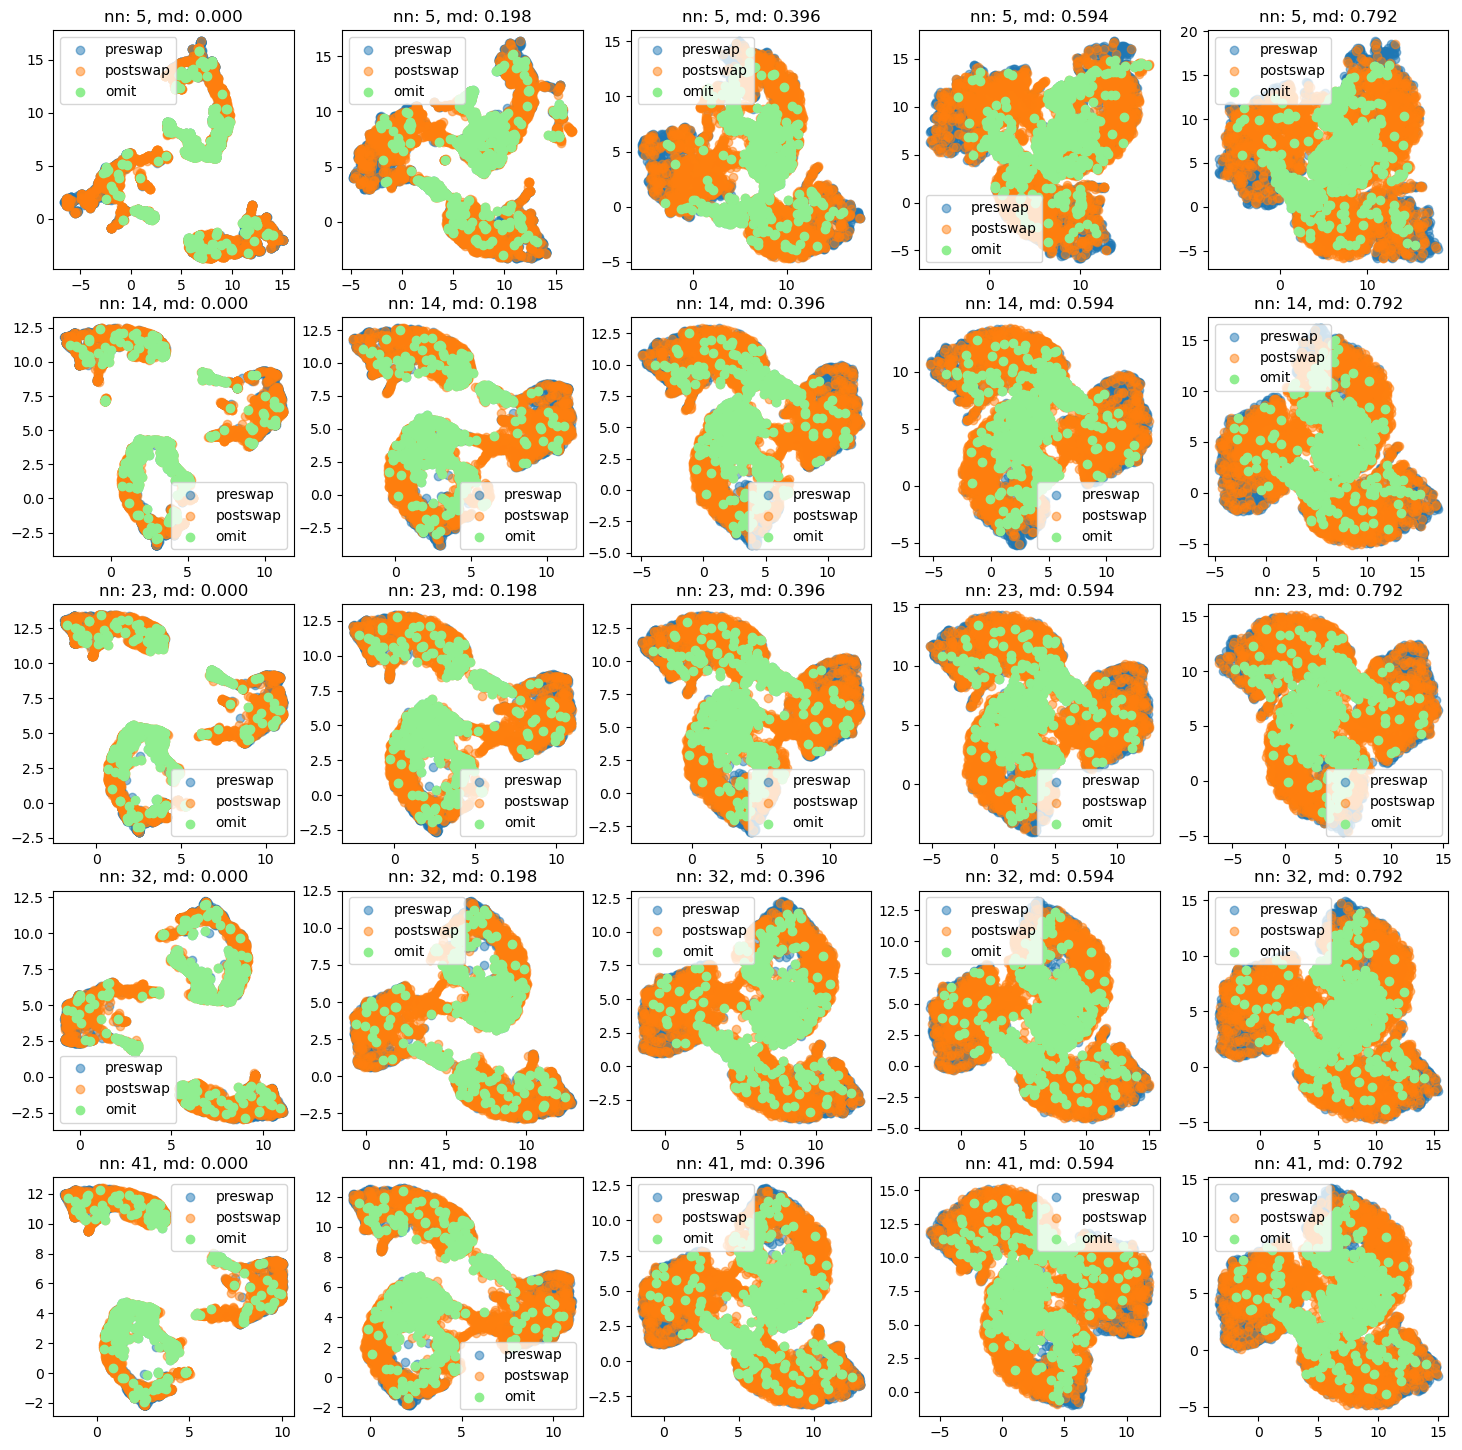

In [3]:
fig, axs = plt.subplots(ncols = 5, nrows = 5, figsize = (18,18))

for i, n_neighbor in enumerate(np.arange(5, 50, 9)):
    for j, min_dist in enumerate(np.arange(0, 0.99, 0.99/5)):
        
        reducer = umap.UMAP(n_neighbors=int(n_neighbor), min_dist=min_dist)
        

        embedding = reducer.fit_transform(licks_na_free)

        pre_trials = embedding[trials_na_free.trial_type == 'pre_swap']
        post = embedding[trials_na_free.trial_type == 'post_swap']

        axs[i,j].scatter(pre_trials[:,0], pre_trials[:,1], alpha = 0.5, label = 'preswap')
        axs[i,j].scatter(post[:,0], post[:,1], alpha = 0.5, label = 'postswap')

        axs[i,j].scatter(embedding[trials_na_free.omit.values, 0], embedding[trials_na_free.omit.values, 1], color = 'lightgreen', label = 'omit')
        axs[i,j].legend()
        axs[i,j].set_title(f'nn: {int(n_neighbor)}, md: {min_dist:.3f}')

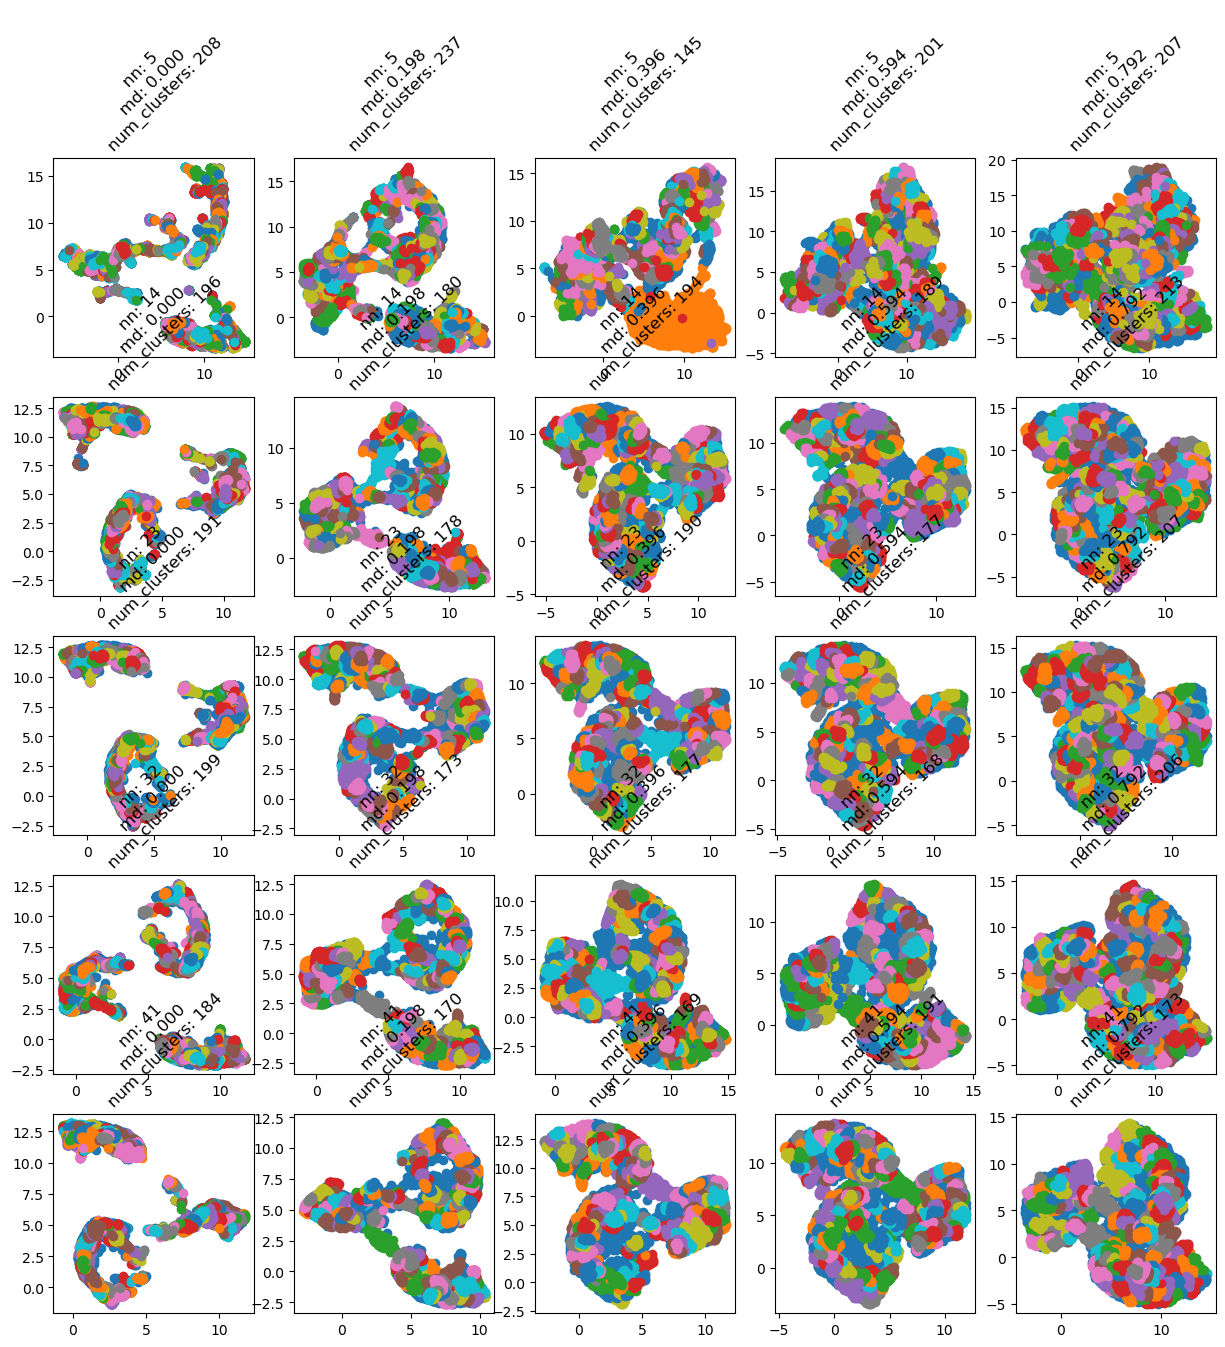

In [4]:
fig, axs = plt.subplots(ncols = 5, nrows = 5, figsize = (15,15))
for i, n_neighbor in enumerate(np.arange(5, 50, 9)):
    for j, min_dist in enumerate(np.arange(0, 0.99, 0.99/5)):
        
        reducer = umap.UMAP(n_neighbors=int(n_neighbor), min_dist=min_dist)
        labels = hdbscan.HDBSCAN(
                    min_samples=2,
                    min_cluster_size=10,
                ).fit_predict(embedding)

        embedding = reducer.fit_transform(licks_na_free)
        
        for label in np.unique(labels):
            slicer = labels == label
            axs[i,j].scatter(embedding[slicer, 0], embedding[slicer, 1], )

        axs[i,j].set_title(f'nn: {int(n_neighbor)}\nmd: {min_dist:.3f}\nnum_clusters: {max(labels)}', rotation = 45)

In [5]:
%matplotlib widget
fig.show()

/tmp/ipykernel_2686297/765579653.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [6]:

# reducer = umap.UMAP(n_neighbors=5, min_dist=0.4)
reducer = umap.UMAP(n_neighbors=30, min_dist=0.4)

embedding = reducer.fit_transform(licks_na_free)



In [7]:
new_labels = hdbscan.HDBSCAN(
    min_samples=2,
    min_cluster_size=6,

).fit_predict(embedding)

In [8]:
labels = new_labels

In [9]:
trials_na_free['hdb_labels'] = labels

[0 2 8 7 3 1 6 4 5 9]


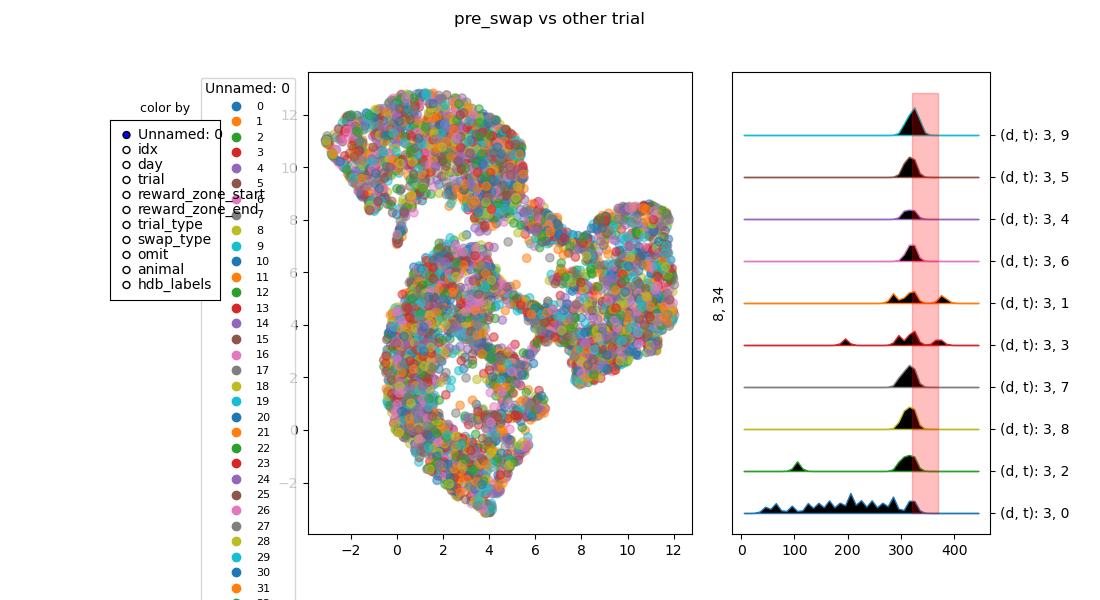

In [12]:
%matplotlib widget
import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker

bin_centers = np.arange(5,455,10)

linker = TrialPlotLinker(trials_na_free)

fig = plt.figure(figsize = (11,6))
fig.suptitle('pre_swap vs other trial')
axes_dict = fig.subplot_mosaic([['lick_umap', 'lick_umap', 'lick_raster'],
                                    ['lick_umap','lick_umap', 'lick_raster'],
                                    ],
                                height_ratios = [3.0,2.0],
                                width_ratios = [2.0,2.0,3])
ax_umap= axes_dict['lick_umap']

scatter_1 = ax_umap.scatter(embedding[:,0], embedding[:,1], alpha = 0.5, label = 'preswap')

ax_umap.legend()

scatter_meta = trials_na_free
add_hover(scatter_1, scatter_meta)
color_selector = ColorSelector(scatter_1,scatter_meta)

sel = add_selectors(scatter_1, linker, scatter_meta)


umap_view = ppf.ScatterView(data = embedding, meta = scatter_meta, plt_obj = scatter_1)


lick_ax = axes_dict['lick_raster']
lick_ax.tick_params(right=True, labelright=True, left=False, labelleft=False)

raster_view = ppf.LickRasterView(licks_na_free, bin_centers, scatter_meta, lick_ax)
raster_view.link_colormaps(color_selector.get_color_linker(), )
raster_view.sort_by({'hdb_labels':'descending', 'day':'descending', 'trial':'descending'})
color_selector.add_after_recolor_call(raster_view.update_linked_colors)

linker.add_views([umap_view, raster_view]) 

In [ ]:
def get_key_val_average(data, key, value, meta, method = np.mean, axis = 0):
    return method(data[meta[key]==value], axis = axis)



In [14]:
def get_reward_zone_outliers(cluster_column_name, value, meta):

    meta_slice = meta.loc[meta[cluster_column_name] == value]

    rzones = meta_slice['reward_zone_start'].value_counts()
    
    if len(rzones)>1:
        return meta_slice
    else:
        return None
    


In [15]:
trials_na_free.loc[trials_na_free['hdb_labels']==30]['reward_zone_start'].value_counts().index

Int64Index([80], dtype='int64')

In [16]:
outliers = {}
for animal in trials_na_free.animal.unique():

    
    for day in trials_na_free.day.unique():
        ani_slice = trials_na_free.loc[(trials_na_free.animal == animal)&(trials_na_free.day == day)]
        for i in range( trials_na_free.hdb_labels.max()+1 ):
            out = get_reward_zone_outliers('hdb_labels', i, ani_slice)
            if not out is None:
                if animal in outliers.keys() and day in outliers[animal].keys():

                    outliers[animal][day][i] = out
                elif animal in outliers.keys():
                    outliers[animal][day] = {i:out}
                else:
                    outliers[animal] = {day:{i:out}}

In [ ]:
outliers['GCAMP4'].keys()

In [ ]:
for animal in outliers.keys():
    print(f'------ {animal}')
    for day in outliers[animal].keys():
        print(f'----------- {day}\n-------------- {outliers[animal][day].keys()}')


------ GCAMP3
----------- 7
-------------- dict_keys([21])
----------- 10
-------------- dict_keys([28])
----------- 12
-------------- dict_keys([38])
------ GCAMP4
----------- 5
-------------- dict_keys([38, 44])
----------- 7
-------------- dict_keys([147, 149])
----------- 8
-------------- dict_keys([274])
----------- 10
-------------- dict_keys([191])
----------- 14
-------------- dict_keys([292])
------ GCAMP7
----------- 3
-------------- dict_keys([44])
----------- 5
-------------- dict_keys([199])
----------- 7
-------------- dict_keys([117, 124])
----------- 8
-------------- dict_keys([125])
----------- 10
-------------- dict_keys([234])
----------- 12
-------------- dict_keys([192])
------ GCAMP11
----------- 5
-------------- dict_keys([38, 40])
----------- 7
-------------- dict_keys([116, 300])
----------- 10
-------------- dict_keys([207])
------ GCAMP12
----------- 3
-------------- dict_keys([48, 110])
----------- 10
-------------- dict_keys([38])
------ GCAMP13
-----------

In [18]:

animal = 'GCAMP14'
day = 7
label = 6
start_idx =trials_na_free.loc[(trials_na_free.animal == animal)&(trials_na_free.day==day)&(trials_na_free.hdb_labels == label), 'idx'].values


In [19]:
start_idx

array([], dtype=int64)

[0 2 8 7 3 1 6 4 5 9]
[]


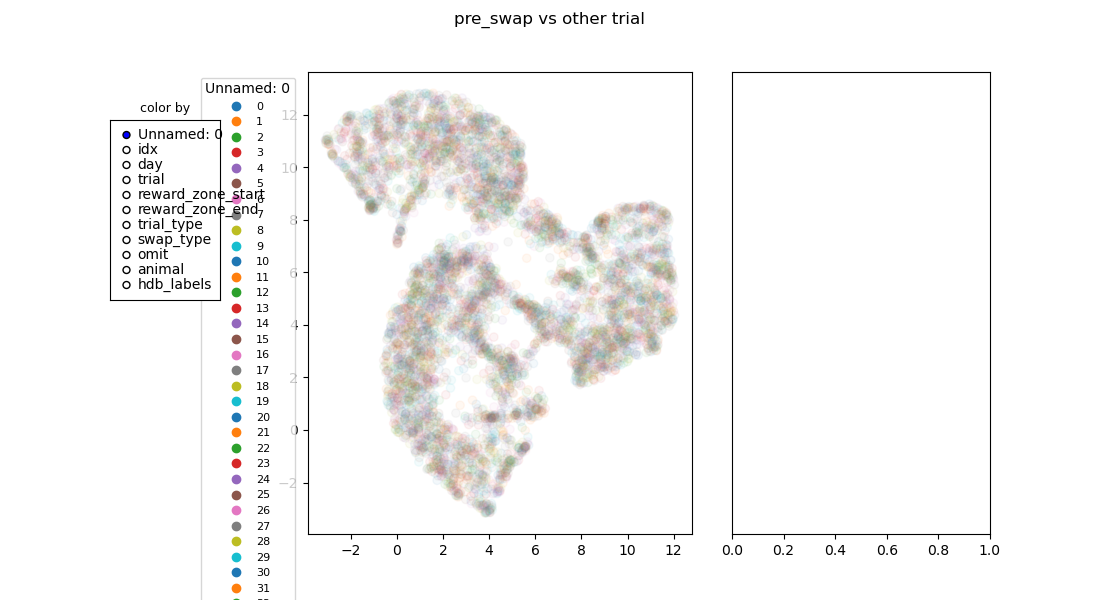

In [ ]:
%matplotlib widget
import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker

bin_centers = np.arange(5,455,10)

linker = TrialPlotLinker(trials_na_free)

fig = plt.figure(figsize = (11,6))
fig.suptitle('pre_swap vs other trial')
axes_dict = fig.subplot_mosaic([['lick_umap', 'lick_umap', 'lick_raster'],
                                    ['lick_umap','lick_umap', 'lick_raster'],
                                    ],
                                height_ratios = [3.0,2.0],
                                width_ratios = [2.0,2.0,3])
ax_umap= axes_dict['lick_umap']

scatter_1 = ax_umap.scatter(embedding[:,0], embedding[:,1], alpha = 0.5, label = 'preswap')

ax_umap.legend()

scatter_meta = trials_na_free
add_hover(scatter_1, scatter_meta)
color_selector = ColorSelector(scatter_1,scatter_meta)

sel = add_selectors(scatter_1, linker, scatter_meta)


umap_view = ppf.ScatterView(data = embedding, meta = scatter_meta, plt_obj = scatter_1)


lick_ax = axes_dict['lick_raster']
lick_ax.tick_params(right=True, labelright=True, left=False, labelleft=False)

raster_view = ppf.LickRasterView(licks_na_free, bin_centers, scatter_meta, lick_ax)
raster_view.link_colormaps(color_selector.get_color_linker(), )
raster_view.sort_by({'hdb_labels':'descending', 'day':'descending', 'trial':'descending'})
color_selector.add_after_recolor_call(raster_view.update_linked_colors)

linker.add_views([umap_view, raster_view]) 
raster_view.update(start_idx)
umap_view.update(start_idx)


In [24]:
animal = 'GCAMP13'
day = 5 
label = 134
new_idx =trials_na_free.loc[(trials_na_free.animal == animal)&(trials_na_free.day==day)&(trials_na_free.hdb_labels == label), 'idx'].values

raster_view.update(new_idx)
umap_view.update(new_idx)


[54 26  6]


In [ ]:
outliers['GCAMP13'][5][]

{78:       Unnamed: 0   idx  day  trial  reward_zone_start  reward_zone_end  \
 2975          20  3025    5     20                200              250   
 3030          75  3080    5     75                 80              130   
 
      trial_type      swap_type   omit   animal  hdb_labels  
 2975   pre_swap  swap_proximal  False  GCAMP13          78  
 3030  post_swap  swap_proximal   True  GCAMP13          78  ,
 119:       Unnamed: 0   idx  day  trial  reward_zone_start  reward_zone_end  \
 2957           2  3007    5      2                200              250   
 3004          49  3054    5     49                 80              130   
 
      trial_type      swap_type   omit   animal  hdb_labels  
 2957   pre_swap  swap_proximal  False  GCAMP13         119  
 3004  post_swap  swap_proximal   True  GCAMP13         119  ,
 134:       Unnamed: 0   idx  day  trial  reward_zone_start  reward_zone_end  \
 2961           6  3011    5      6                200              250   
 2981   

In [ ]:
trials_na_free.loc[trials_na_free.idx.isin(start_idx)]

In [ ]:
trials_na_free.loc[(trials_na_free.animal == animal)&(trials_na_free.day==day)&(trials_na_free.hdb_labels == label), 'idx'].values

In [ ]:
get_key_val_average(licks_na_free, key = 'hdb_labels', value = 5, meta = trials_na_free)

In [ ]:
label_max = trials_na_free.hdb_labels.max()+1
mean_dat = np.asarray([get_key_val_average(licks_na_free, key = 'hdb_labels', value = val, meta = trials_na_free) for val in range(label_max)])



In [ ]:
mean_dat.shape

In [ ]:
fig, ax = plt.subplots(figsize = (10, 0.25*label_max))
new_meta = pd.DataFrame({'idx':[i for i in range(label_max)], 'hdb_label':[i for i in range(label_max)]})
view = ppf.LickRasterView(mean_dat, bins = bin_centers, metadata=new_meta, ax = ax, color_from_metadata=False)
view.update([i for i in range(label_max)])
fig.savefig('licks')

In [ ]:
import scipy.stats as sts

In [ ]:
sts.wasserstein_distance(mean_dat[0], mean_dat[-2])

In [ ]:
from scipy.spatial.distance import pdist, squareform



dat = pdist(mean_dat, metric=sts.wasserstein_distance)
D = squareform(dat)        


In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(np.triu(D))
fig.colorbar(im)

In [ ]:
fig, ax = plt.subplots(figsize = (10, 0.25*3))
new_meta = pd.DataFrame({'idx':[i for i in range(label_max)], 'hdb_label':[i for i in range(label_max)]})
view = ppf.LickRasterView(mean_dat, bins = bin_centers, metadata=new_meta, ax = ax, color_from_metadata=False)
view.update([78, 42, 77])

In [ ]:
dat.shape

In [ ]:
fig, ax = plt.subplots()

ax.hist(dat[[i for i in range(int(len(dat)/2))]] , bins = 'auto')